In [2]:
!mkdir -p ~/.kaggle
!echo "KGAT_ca2e40564860831c9a588f182fb935ca" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

In [3]:
!pip install -q kaggle

In [4]:
!kaggle datasets download -d salader/dogsvscats --unzip

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:06<00:00, 181MB/s]



In [5]:
!pip install -q tensorflow

In [6]:
import sys
print(sys.executable)

/usr/bin/python3


In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Dropout

In [10]:
train_ds = keras.utils.image_dataset_from_directory(
   directory="/content/catsvsdogs",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory="/content/catsvsdogs",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256),
    shuffle=False
)

Found 25000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.


In [11]:
#Normalise
def process(image,label):
    image = tf.cast(image/255.0 ,tf.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [12]:
#create cnn model
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [15]:
history = model.fit(train_ds,epochs=10, validation_data = validation_ds)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 97s 112ms/step - accuracy: 0.7999 - loss: 0.5104 - val_accuracy: 0.8000 - val_loss: 0.5006
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 91s 116ms/step - accuracy: 0.8000 - loss: 0.5025 - val_accuracy: 0.8000 - val_loss: 0.5005
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 90s 115ms/step - accuracy: 0.8000 - loss: 0.5023 - val_accuracy: 0.8000 - val_loss: 0.5014
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 115ms/step - accuracy: 0.8000 - loss: 0.5014 - val_accuracy: 0.8000 - val_loss: 0.5032
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 104ms/step - accuracy: 0.8000 - loss: 0.4970 - val_accuracy: 0.8001 - val_loss: 0.4969
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 105ms/step - accuracy: 0.8021 - loss: 0.4854 - val_accuracy: 0.8008 - val_loss: 0.4931
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 90s 115ms/step - accuracy: 0.8116 - loss: 0.4583 - val_accuracy: 0.7979 - val_loss: 0.4995
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 116ms/step - accuracy: 0.8358 - loss:

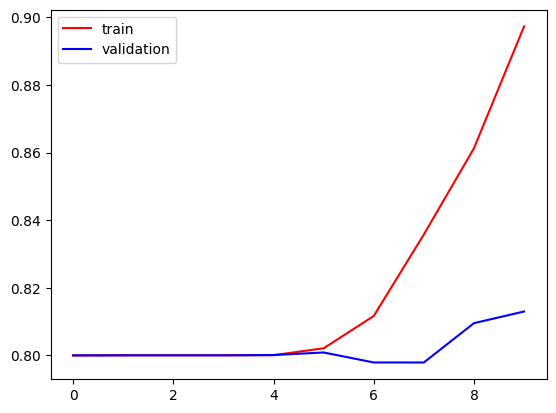

In [16]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color = 'red',label = 'train')
plt.plot(history.history['val_accuracy'], color = 'blue', label = 'validation')
plt.legend()
plt.show()

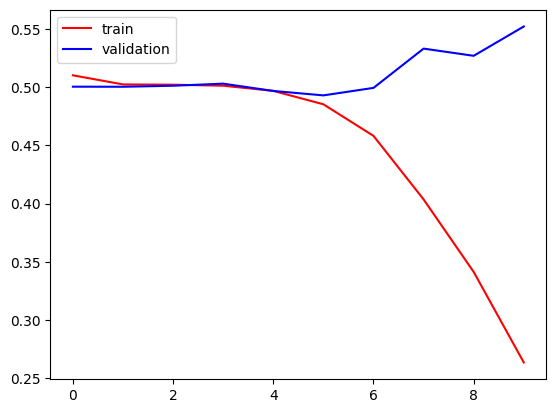

In [17]:
plt.plot(history.history['loss'], color = 'red', label = 'train')
plt.plot(history.history['val_loss'], color = 'blue', label = 'validation')
plt.legend()
plt.show()

In [18]:
import cv2
print(cv2.__version__)

4.13.0


In [19]:
test_img = cv2.imread('/content/test/dogs')

In [24]:
import os

print(os.listdir("/content/test/cats")[:10])
print(os.listdir("/content/test/dogs")[:10])

['cat.4044.jpg', 'cat.4221.jpg', 'cat.11045.jpg', 'cat.12118.jpg', 'cat.344.jpg', 'cat.6702.jpg', 'cat.2640.jpg', 'cat.3200.jpg', 'cat.10532.jpg', 'cat.2567.jpg']
['dog.6790.jpg', 'dog.9711.jpg', 'dog.10126.jpg', 'dog.5032.jpg', 'dog.1480.jpg', 'dog.4044.jpg', 'dog.2958.jpg', 'dog.8634.jpg', 'dog.4202.jpg', 'dog.1272.jpg']


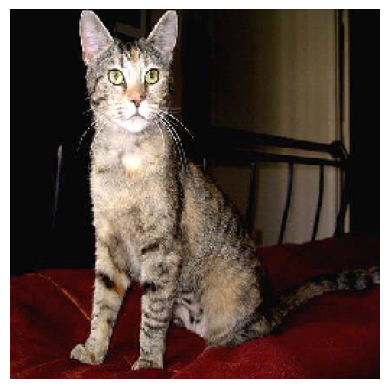

In [26]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img = image.load_img("/content/test/cats/cat.10000.jpg",
                     target_size=(256,256))

plt.imshow(img)
plt.axis("off")
plt.show()

In [29]:
print(img.size)

(256, 256)


In [33]:
test_img = cv2.resize(test_img,(256,256))

In [34]:
test_input = test_img.reshape((1,256,256,3))

In [35]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[0.]], dtype=float32)